# HDFC — Parkinson realized volatility (rolling 7d / 30d / 90d)

**Parkinson** high–low estimator (single day variance proxy):
\[
\sigma^2_t = \frac{1}{4\ln 2}\left(\ln\frac{H_t}{L_t}\right)^2
\]

For an **\(n\)-day** Parkinson realized volatility (annualized), we take the rolling **mean** of daily \(\sigma^2_t\) over \(n\) trading days and set
\[
\text{vol}_{\mathrm{ann},t} = \sqrt{252 \times \overline{\sigma^2}_{t;n}}.
\]

**Ticker:** `HDFCBANK.NS` (HDFC Bank; adjust if you need a different line such as HDFC AMC listed separately).

**Requirements:** `pip install yfinance pandas numpy matplotlib`

In [29]:
from nselib import capital_market
df = capital_market.price_volume_data('HDFCBANK', '07-03-2026', '07-05-2026')
df

,Symbol,Series,Date,PrevClose,OpenPrice,HighPrice,LowPrice,LastPrice,ClosePrice,AveragePrice,TotalTradedQuantity,Turnover₹,No.ofTrades
0,HDFCBANK,EQ,07-May-2026,796.55,794.00,801.55,788.55,795.55,796.05,795.15,"4,61,37,553","36,68,63,70,164.65","3,69,255"
1,HDFCBANK,EQ,06-May-2026,772.30,775.15,798.95,773.50,796.00,796.55,785.36,"3,55,30,831","27,90,44,17,066.50","4,02,081"
2,HDFCBANK,EQ,05-May-2026,779.40,774.40,776.90,763.70,773.20,772.30,771.31,"3,88,87,657","29,99,43,77,836.65","4,91,093"
3,HDFCBANK,EQ,04-May-2026,771.70,772.60,786.60,772.60,779.50,779.40,779.72,"2,90,28,060","22,63,37,11,388.45","3,82,758"
4,HDFCBANK,EQ,30-Apr-2026,779.00,770.00,778.80,762.25,774.75,771.70,770.36,"4,79,98,755","36,97,63,52,716.85","5,68,313"
5,HDFCBANK,EQ,29-Apr-2026,782.55,785.50,790.00,777.35,778.30,779.00,783.90,"2,57,99,963","20,22,47,13,818.45","4,68,032"
6,HDFCBANK,EQ,28-Apr-2026,789.80,785.00,794.50,778.30,782.35,782.55,786.39,"3,53,66,803","27,81,22,42,540.60","3,33,592"
7,HDFCBANK,EQ,27-Apr-2026,784.85,787.50,793.00,785.00,790.00,789.80,789.16,"1,81,15,375","14,29,59,37,140.45","2,78,374"
8,HDFCBANK,EQ,24-Apr-2026,784.35,777.30,787.60,777.00,785.15,784.85,782.99,"2,77,20,358","21,70,47,72,419.30","3,63,338"
9,HDFCBANK,EQ,23-Apr-2026,799.90,792.00,796.65,782.50,783.90,784.35,788.13,"3,76,77,616","29,69,48,61,381.85","4,90,484"


            park_var_daily  parkinson_rv_7d  parkinson_rv_30d
Date                                                         
2026-04-30        0.000166         0.165246          0.256590
2026-05-04        0.000116         0.164198          0.251306
2026-05-05        0.000106         0.163107          0.251457
2026-05-06        0.000378         0.194492          0.255757
2026-05-07        0.000096         0.199910          0.237006


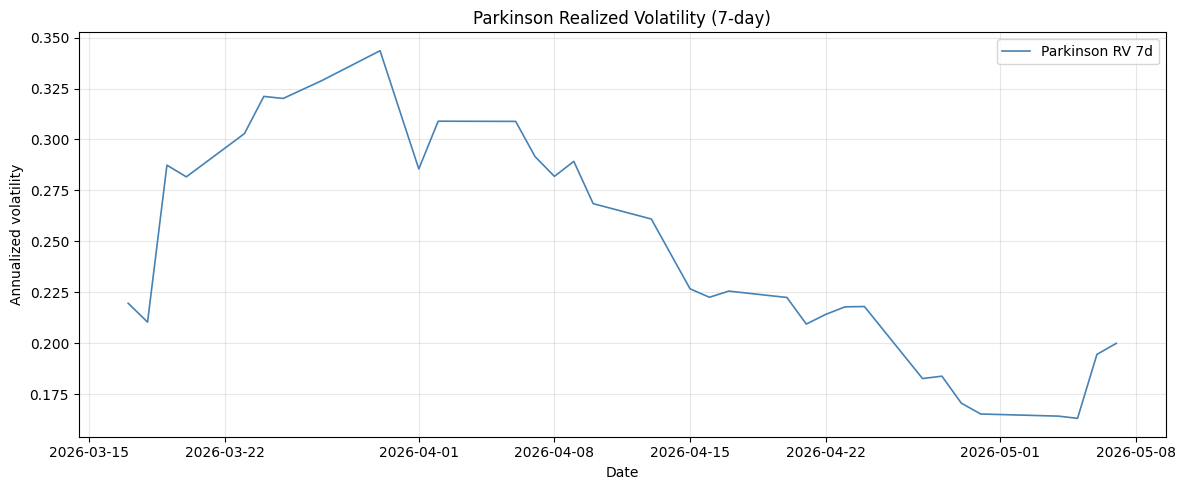

In [31]:
# Using existing `df` (from nselib) to compute Parkinson realized vol (7d, 30d)
# Assumes df already exists in memory.
import numpy as np 
import pandas as pd
# Resolve High/Low column names robustly
cols_lc = {c.lower(): c for c in df.columns}
high_col = (
    cols_lc.get("high")
    or cols_lc.get("highprice")
    or cols_lc.get("high price")
)
low_col = (
    cols_lc.get("low")
    or cols_lc.get("lowprice")
    or cols_lc.get("low price")
)
if high_col is None or low_col is None:
    raise ValueError(f"Could not find High/Low columns in df. Available columns: {list(df.columns)}")

# If Date exists, use it as index for plotting
if "Date" in df.columns:
    df2 = df.copy()
    # nselib often returns dates like 30-Apr-2026 (abbrev month), sometimes mixed formats
    df2["Date"] = pd.to_datetime(df2["Date"], format="mixed", dayfirst=True, errors="coerce")
    df2 = df2.dropna(subset=["Date"]).sort_values("Date").set_index("Date")
else:
    df2 = df.copy()
    if not isinstance(df2.index, pd.DatetimeIndex):
        df2.index = pd.to_datetime(df2.index)
    df2 = df2.sort_index()

high = pd.to_numeric(df2[high_col], errors="coerce")
low = pd.to_numeric(df2[low_col], errors="coerce")
valid = pd.DataFrame({"High": high, "Low": low}).dropna()

# Daily Parkinson variance proxy
park_var_daily = (1.0 / (4.0 * np.log(2.0))) * (np.log(valid["High"] / valid["Low"]) ** 2)

# Rolling Parkinson realized vol (annualized)
trading_days = 252
rv_7d = np.sqrt(trading_days * park_var_daily.rolling(7, min_periods=7).mean()).rename("parkinson_rv_7d")
rv_30d = np.sqrt(trading_days * park_var_daily.rolling(30, min_periods=30).mean()).rename("parkinson_rv_30d")

# Attach back for convenience
df_parkinson = pd.concat([park_var_daily.rename("park_var_daily"), rv_7d, rv_30d], axis=1)
print(df_parkinson.tail())

# Plot only 7-day realized vol
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(rv_7d.index, rv_7d.values, color="steelblue", linewidth=1.2, label="Parkinson RV 7d")
ax.set_title("Parkinson Realized Volatility (7-day)")
ax.set_ylabel("Annualized volatility")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [32]:
from nselib import derivatives
import pandas as pd


In [ ]:
# 7-day and 30-day moving averages of realized volatility series
# (computed from the rv_7d and rv_30d series above)
rv_7d_ma7 = rv_7d.rolling(7, min_periods=7).mean().rename("rv_7d_ma7")
rv_7d_ma30 = rv_7d.rolling(30, min_periods=30).mean().rename("rv_7d_ma30")

rv_30d_ma7 = rv_30d.rolling(7, min_periods=7).mean().rename("rv_30d_ma7")
rv_30d_ma30 = rv_30d.rolling(30, min_periods=30).mean().rename("rv_30d_ma30")

ma_table = pd.concat([rv_7d, rv_30d, rv_7d_ma7, rv_7d_ma30, rv_30d_ma7, rv_30d_ma30], axis=1)
print(ma_table.tail(10))

print("\nLatest values:")
print(ma_table.dropna(how="all").iloc[-1])

In [37]:
# Example: Get historical price data for SBI Futures
fut_df = derivatives.future_price_volume_data(
    symbol='SBIN', 
    instrument='FUTSTK', 
    period='1M'
)

# Example: Get historical data for Nifty Call Options
opt_df = derivatives.option_price_volume_data(
    symbol='HDFCBANK', 
    instrument='OPTSTK', 
    option_type='CE', 
    period='1M'
)


In [38]:
opt_df

,TIMESTAMP,INSTRUMENT,SYMBOL,EXPIRY_DT,STRIKE_PRICE,OPTION_TYPE,MARKET_TYPE,OPENING_PRICE,TRADE_HIGH_PRICE,TRADE_LOW_PRICE,CLOSING_PRICE,LAST_TRADED_PRICE,PREV_CLS,SETTLE_PRICE,TOT_TRADED_QTY,TOT_TRADED_VAL,OPEN_INT,CHANGE_IN_OI,MARKET_LOT,UNDERLYING_VALUE
0,08-May-2026,OPTSTK,HDFCBANK,26-May-2026,910,CE,N,0.65,0.65,0.40,0.45,0.45,0.75,0.45,271700,2473.87,286550,9350,550,780.85
1,08-May-2026,OPTSTK,HDFCBANK,26-May-2026,960,CE,N,0.25,0.25,0.25,0.25,0.25,0.35,0.00,51700,496.45,99550,-19250,550,780.85
2,08-May-2026,OPTSTK,HDFCBANK,26-May-2026,780,CE,N,23.10,23.55,18.00,19.35,19.15,27.35,19.35,6408600,51257.92,3892900,535700,550,780.85
3,08-May-2026,OPTSTK,HDFCBANK,26-May-2026,885,CE,N,1.00,1.10,0.70,0.90,0.90,1.25,0.90,124300,1101.21,52250,-36850,550,780.85
4,08-May-2026,OPTSTK,HDFCBANK,26-May-2026,915,CE,N,0.00,0.00,0.00,0.85,0.85,0.85,0.05,0,0.00,24200,0,550,780.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2975,09-Apr-2026,OPTSTK,HDFCBANK,28-Apr-2026,920,CE,N,1.75,1.75,1.05,1.15,1.15,1.70,1.15,350350,3227.97,481250,57750,550,797.70
2976,09-Apr-2026,OPTSTK,HDFCBANK,28-Apr-2026,815,CE,N,23.00,23.60,13.70,15.20,15.00,22.30,15.20,3519450,29282.58,1075800,169400,550,797.70
2977,09-Apr-2026,OPTSTK,HDFCBANK,28-Apr-2026,915,CE,N,1.90,1.90,1.25,1.35,1.40,1.90,1.35,125400,1149.29,103400,79750,550,797.70
2978,09-Apr-2026,OPTSTK,HDFCBANK,28-Apr-2026,830,CE,N,16.10,16.10,9.15,10.30,10.10,15.50,10.30,2663100,22406.24,1053250,30800,550,797.70
